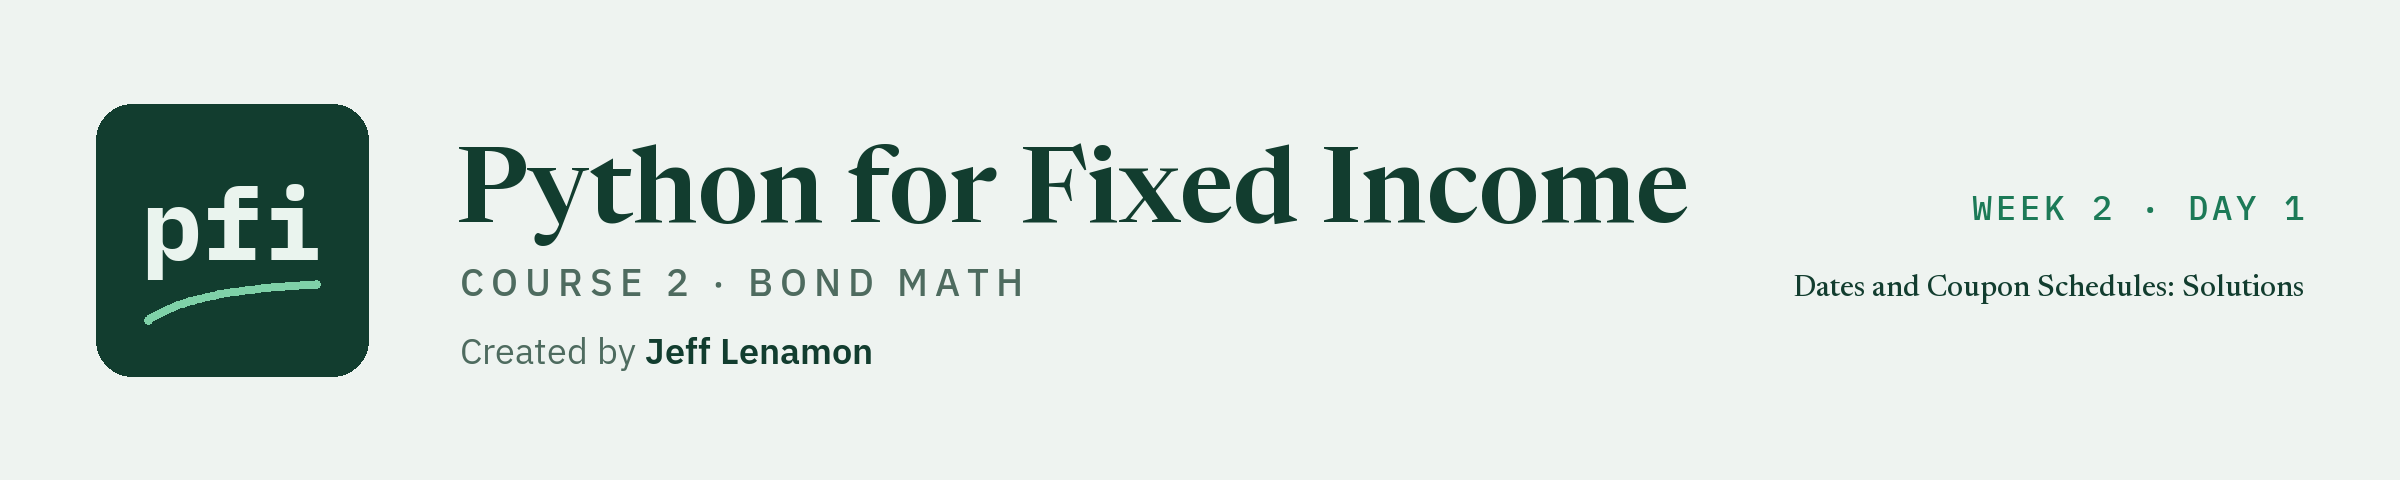

# Dates and Coupon Schedules: Solutions

Week 2, Day 1. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week2/day1/06_dates_and_coupon_schedules_solutions.ipynb)

This notebook stands on its own. Its setup writes `bondmath.py` and `test_bondmath.py` as they stand at the end of today, so the exercises can be run without the lesson.

Q. Set up today's work folder.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_06_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_06_i4bru12c, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the end of today.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]


def test_convert_yield_matches_excel_effect_and_nominal():
    # EFFECT restates a rate compounded `frequency` times a year as an annually compounded rate
    for row in tvm_rows("EFFECT"):
        result = bondmath.convert_yield(float(row["rate_pct"]), int(row["frequency"]), 1)
        # Excel returns a decimal, bondmath a percent
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]
    # NOMINAL goes the other way: from annual compounding to `frequency` times a year
    for row in tvm_rows("NOMINAL"):
        result = bondmath.convert_yield(float(row["rate_pct"]), 1, int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-9), row["case_id"]


def test_convert_yield_round_trip():
    # semiannual to quarterly and back gives the yield we started with
    quarterly = bondmath.convert_yield(6.0, 2, 4)
    assert bondmath.convert_yield(quarterly, 4, 2) == pytest.approx(6.0, abs=1e-12)


def test_yield_from_price_matches_excel():
    # Excel's RATE, times the frequency, is the annual yield as a decimal
    for row in tvm_rows("RATE"):
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]) * 100, abs=1e-6), row["case_id"]
    # Excel's YIELD on the coupon-date rows, already in percent in the reference file
    for row in REFERENCE:
        if row["coupdaybs"] != "0":
            continue
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.yield_from_price(float(row["coupon_pct"]), float(row["price"]), years, frequency)
        assert result == pytest.approx(float(row["yield_pct_from_price"]), abs=1e-6), row["case_id"]


def test_yield_raises_outside_bracket():
    # no yield between -5 and 100 percent gives a price of 1,000 or of 0.01
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 1000.0, 5, 2)
    with pytest.raises(ValueError):
        bondmath.yield_from_price(6.0, 0.01, 5, 2)


def test_yield_round_trip():
    # price a bond from a yield, then solve the yield back from that price
    bond_price = bondmath.price_from_yield(5.25, 6.1, 7, 2)
    assert bondmath.yield_from_price(5.25, bond_price, 7, 2) == pytest.approx(6.1, abs=1e-8)


def test_par_bond_prices_at_100():
    # a coupon equal to the yield prices at 100 for every frequency and term
    for frequency in (1, 2, 4):
        for years in (1, 2, 5, 10, 30):
            assert bondmath.price_from_yield(5.5, 5.5, years, frequency) == pytest.approx(100, abs=1e-9)


def test_price_falls_as_yield_rises():
    # price a 10-year 6 percent bond at yields from 2 to 12 percent
    prices = [bondmath.price_from_yield(6.0, yield_pct, 10, 2) for yield_pct in (2, 4, 6, 8, 10, 12)]
    # every price is below the one before it
    for earlier, later in zip(prices, prices[1:]):
        assert later < earlier


def test_add_months_clamps_to_month_end():
    # 31 August back 6 months: 28 February, or 29 February in a leap year
    assert bondmath.add_months(date(2031, 8, 31), -6) == date(2031, 2, 28)
    assert bondmath.add_months(date(2032, 8, 31), -6) == date(2032, 2, 29)
    # 31 January forward 1 month
    assert bondmath.add_months(date(2027, 1, 31), 1) == date(2027, 2, 28)
    # a day every month has is kept, across a year end
    assert bondmath.add_months(date(2026, 11, 15), 3) == date(2027, 2, 15)


def test_coupon_dates_match_excel():
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        dates = bondmath.coupon_dates(settlement, maturity, int(row["frequency"]))
        # [0] is COUPPCD, [1] is COUPNCD, and the number of dates after [0] is COUPNUM
        assert dates[0] == date.fromisoformat(row["couppcd"]), row["case_id"]
        assert dates[1] == date.fromisoformat(row["coupncd"]), row["case_id"]
        assert len(dates) - 1 == int(row["coupnum"]), row["case_id"]

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield', 'convert_yield', 'yield_from_price', 'add_months', 'coupon_dates']


## Exercises

The exercises use the second set of four bonds from week 1, settled on the same day as the lesson's bonds, 30 November 2026. All four mature on 30 September, a month end. The issuers are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second set of bonds and defines `check`, a small function that marks your answers.

In [5]:
import calendar
from datetime import date, timedelta

exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "rating": ['BBB-', 'A', 'BBB-', 'B'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    # maturity as text for now: section 6.1 turns it into dates
    "maturity": ['2030-09-30', '2028-09-30', '2032-09-30', '2034-09-30'],
})
exercise_bonds["maturity_date"] = [date.fromisoformat(text) for text in exercise_bonds["maturity"]]
settlement = date(2026, 11, 30)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,maturity_date
0,99005FZA4,Ostrevale Telecom,OSTV,BBB-,5.625,2030-09-30,2030-09-30
1,99007HZA8,Tarnwick Utilities,TRNW,A,4.375,2028-09-30,2028-09-30
2,99008IZA5,Osmere Chemicals,OSMC,BBB-,5.000,2032-09-30,2032-09-30
3,99009JZA2,Calderby Retail,CLDB,B,8.250,2034-09-30,2034-09-30


### Exercise 1

Q. With `bondmath.coupon_dates`, find the previous coupon, the next coupon, and the coupons left for each exercise bond on 30 November 2026. Store Calderby's next coupon date, a `date`, in **ex1_next**, and the total number of coupons left across the four bonds in **ex1_total**.

In [6]:
rows = []
for bond in exercise_bonds.itertuples():
    dates = bondmath.coupon_dates(settlement, bond.maturity_date)
    rows.append({"ticker": bond.ticker, "previous": dates[0], "next": dates[1], "coupons_left": len(dates) - 1})
ex1_schedule = pd.DataFrame(rows)
print(ex1_schedule)

ex1_next = ex1_schedule.loc[ex1_schedule["ticker"] == "CLDB", "next"].iloc[0]
ex1_total = int(ex1_schedule["coupons_left"].sum())
print(f"Calderby's next coupon: {ex1_next}. Coupons left across the four: {ex1_total}")

  ticker    previous        next  coupons_left
0   OSTV  2026-09-30  2027-03-31             8
1   TRNW  2026-09-30  2027-03-31             4
2   OSMC  2026-09-30  2027-03-31            12
3   CLDB  2026-09-30  2027-03-31            16
Calderby's next coupon: 2027-03-31. Coupons left across the four: 40


* All four share the previous coupon, 30 September 2026, and the next, 31 March 2027: the month-end rule, because 30 September is the last day of September.
* Coupons left: Ostrevale 8, Tarnwick 4, Osmere 12, Calderby 16, 40 in all.
* Excel agrees: the week 2 rows of the reference file hold `COUPPCD`, `COUPNCD`, and `COUPNUM` for all four, for example `=COUPNUM(DATE(2026,11,30),DATE(2034,9,30),2,0)` returns 16 for Calderby.

In [7]:
check("Exercise 1 Calderby next coupon", ex1_next, date(2027, 3, 31))
check("Exercise 1 total coupons left", ex1_total, 40)

Exercise 1 Calderby next coupon: correct
Exercise 1 total coupons left: correct


### Exercise 2

Q. From Calderby's `coupon_dates` list, compute the length of every coupon period in actual days (from each date to the next). Store the shortest in **ex2_shortest**, the longest in **ex2_longest**, and the number of periods that are 183 days long in **ex2_count_183**.

In [8]:
calderby_dates = bondmath.coupon_dates(settlement, date(2034, 9, 30))
lengths = [(later - earlier).days for earlier, later in zip(calderby_dates, calderby_dates[1:])]
print(f"period lengths: {lengths}")

ex2_shortest, ex2_longest = min(lengths), max(lengths)
ex2_count_183 = lengths.count(183)
print(f"shortest {ex2_shortest}, longest {ex2_longest}, periods of 183 days: {ex2_count_183}")

period lengths: [182, 183, 183, 183, 182, 183, 182, 183, 182, 183, 183, 183, 182, 183, 182, 183]
shortest 182, longest 183, periods of 183 days: 10


* 16 periods: 6 of 182 days and 10 of 183. Every period from 31 March to 30 September is 183 days. A period from 30 September to 31 March is 182 days, or 183 when it holds a 29 February (the March of 2028 and of 2032).
* Under 30/360 each of these periods is 180 days. Day 7 shows where each count is used.

In [9]:
check("Exercise 2 shortest period", ex2_shortest, 182)
check("Exercise 2 longest period", ex2_longest, 183)
check("Exercise 2 periods of 183 days", ex2_count_183, 10)

Exercise 2 shortest period: correct
Exercise 2 longest period: correct
Exercise 2 periods of 183 days: correct


### Exercise 3

Q. Add a function to your module. `coupons_remaining(settlement, maturity, frequency=2)` returns the number of coupons still to be paid after settlement, as Excel's `COUPNUM` does. Write the docstring first: units, convention, and the Excel formula. Use `coupon_dates` inside it. Then add a test to `test_bondmath.py`, called `test_coupons_remaining_matches_excel_coupnum`, with one case you can check by hand and a loop over every row of `REFERENCE` against its `coupnum`. Run pytest, and store `bondmath.coupons_remaining` for Tarnwick on 30 November 2026 in **ex3_tarnwick**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [10]:
%%writefile -a bondmath.py


def coupons_remaining(settlement: date, maturity: date, frequency: int = 2) -> int:
    """The number of coupons still to be paid after settlement, through maturity.

    Units: dates in, a whole number out. Convention: the coupon schedule of coupon_dates, so a coupon
    paid on the settlement date itself is not counted. Excel: =COUPNUM(settlement, maturity, frequency, 0)
    """
    # coupon_dates starts with the previous coupon, which is already paid
    return len(coupon_dates(settlement, maturity, frequency)) - 1

Appending to bondmath.py


In [11]:
%%writefile -a test_bondmath.py


def test_coupons_remaining_matches_excel_coupnum():
    # a hand case: settled on 30 November 2026, a bond maturing 30 September 2028 has 4 coupons left
    assert bondmath.coupons_remaining(date(2026, 11, 30), date(2028, 9, 30)) == 4
    # Excel's COUPNUM on every row of the reference file
    for row in REFERENCE:
        settlement, maturity = date.fromisoformat(row["settlement"]), date.fromisoformat(row["maturity"])
        assert bondmath.coupons_remaining(settlement, maturity, int(row["frequency"])) == int(row["coupnum"]), row["case_id"]

Appending to test_bondmath.py


In [12]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

................                                                         [100%]
16 passed in 0.09s



In [13]:
# the file changed, so reload before calling the new function
importlib.reload(bondmath)

ex3_tarnwick = bondmath.coupons_remaining(settlement, date(2028, 9, 30))
print(f"Tarnwick, settled {settlement}: {ex3_tarnwick} coupons left")

Tarnwick, settled 2026-11-30: 4 coupons left


* `16 passed`: the 15 tests of the lesson and the new one.
* Tarnwick has 4 coupons left: 31 March and 30 September in 2027 and 2028.
* The function is one line on top of `coupon_dates`: the list minus its first date, the previous coupon, which is already paid. In Excel: `=COUPNUM(DATE(2026,11,30),DATE(2028,9,30),2,0)`, which returns 4.

In [14]:
check("Exercise 3 Tarnwick coupons left", ex3_tarnwick, 4)

Exercise 3 Tarnwick coupons left: correct


### Exercise 4: AI check

You ask an AI assistant to write `coupon_dates` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
The previous coupon date, then every coupon date left through maturity.

Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
is the last day of its month, every coupon date is the last day of its month (Excel's rule).
The previous coupon date is the last one on or before settlement.
So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug: a convention error.

* The bug: each coupon date is stepped from the previous one, `add_months(coupon_date, -step_months)`, and the code relies on `add_months` to handle month ends. It cannot. Once a short month clamps the day, the clamped day carries on to every earlier date. A 31 August maturity drifts to the 28th after the first February: the assistant puts the previous coupon of a bond maturing 2031-08-31 on 2026-08-28, where Excel's `COUPPCD` says 2026-08-31. And a 30 September maturity never reaches 31 March at all, because the 30th is simply kept: Quorvane's next coupon came back as 2027-03-30 instead of 2027-03-31.
* The test caught it on row `edge_coupon_date_3y`: next coupon 2027-03-30 against `COUPNCD` 2027-03-31. Every holdings row before it passed, because no holdings bond matures on a month end or after the 28th. A test on the holdings alone would have missed the bug.
* The fix, in the cell below: decide the month-end rule once from maturity, and count each date from maturity, as the docstring says.

In [15]:
def assistant_coupon_dates(settlement, maturity, frequency=2):
    """The previous coupon date, then every coupon date left through maturity.

Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
is the last day of its month, every coupon date is the last day of its month (Excel's rule).
The previous coupon date is the last one on or before settlement.
So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    step_months = 12 // frequency
    # the fix, part 1: decide once whether maturity is the last day of its month
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # the fix, part 2: count each date from maturity itself, never from the date before it
        coupon_date = bondmath.add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: every coupon on the last day of its month
            coupon_date = date(coupon_date.year, coupon_date.month,
                               calendar.monthrange(coupon_date.year, coupon_date.month)[1])
        dates.append(coupon_date)
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates

In [16]:
# the test, written from Excel's reference rows before the code is trusted
reference = pd.read_csv("bondmath_excel_reference.csv")

for row in reference.itertuples():
    settlement, maturity = date.fromisoformat(row.settlement), date.fromisoformat(row.maturity)
    dates = assistant_coupon_dates(settlement, maturity, int(row.frequency))
    # [0] is COUPPCD, [1] is COUPNCD, and the dates after [0] are COUPNUM
    assert dates[0].isoformat() == row.couppcd, f"{row.case_id}: previous coupon {dates[0]} against COUPPCD {row.couppcd}"
    assert dates[1].isoformat() == row.coupncd, f"{row.case_id}: next coupon {dates[1]} against COUPNCD {row.coupncd}"
    assert len(dates) - 1 == row.coupnum, f"{row.case_id}: {len(dates) - 1} coupons against COUPNUM {row.coupnum}"

print("Every row matches COUPPCD, COUPNCD, and COUPNUM")

Every row matches COUPPCD, COUPNCD, and COUPNUM


In [17]:
ex4_quorvane_next = assistant_coupon_dates(settlement, date(2031, 9, 30))[1]
ex4_august_previous = assistant_coupon_dates(settlement, date(2031, 8, 31))[0]

print(f"Quorvane's next coupon from the fixed function: {ex4_quorvane_next}")
print(f"Previous coupon of a 31 August 2031 maturity: {ex4_august_previous}")

Quorvane's next coupon from the fixed function: 2027-03-31
Previous coupon of a 31 August 2031 maturity: 2026-08-31


* 2027-03-31 and 2026-08-31: the month-end rule, applied from maturity. The fixed function now does what its docstring says.

In [18]:
check("Exercise 4 Quorvane next coupon", ex4_quorvane_next, date(2027, 3, 31))
check("Exercise 4 August previous coupon", ex4_august_previous, date(2026, 8, 31))

Exercise 4 Quorvane next coupon: correct
Exercise 4 August previous coupon: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```